# Projeto G1 — Tema 21: Análise de Streaming de Música e Filmes
**Objetivo:** Desenvolver uma aplicação analítica para investigar padrões de consumo, conteúdos populares e a evolução temporal das principais plataformas do mercado de streaming.

## 1. Introdução ao Problema
Os serviços de streaming revolucionaram o consumo cultural. Nosso objetivo é dissecar esses padrões para entender como, quando e o que o público brasileiro consome.

## 2. Leitura e Preparação dos Dados
Vamos iniciar importando nossas bibliotecas obrigatórias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Leitura dos Dados
df = pd.read_csv('../dados/simulacao_streaming_brasil.csv')

# 4. Limpeza e Preparação
df['data'] = pd.to_datetime(df['data'])
print("Total de registros:", df.shape[0])
df.head()

Total de registros: 4440


,ano,mes,data,plataforma,categoria,genero,titulo,reproducoes,tempo_medio_consumo,usuarios_ativos,assinaturas,avaliacao_media,receita_plataforma,horario_pico
0,2015,1,2015-01-01,Disney+,Música,Drama,Filme Solar,341594,34.0,6819,123531,3.26,2116565.35,08:00
1,2015,1,2015-01-01,Netflix,Série,Pop,Filme Solar,658397,57.6,167007,163372,4.00,1844711.64,12:00
2,2015,1,2015-01-01,Spotify,Podcast,Pop,Filme Solar,639888,66.3,294779,92786,3.79,4149626.64,21:00
3,2015,1,2015-01-01,Prime Video,Podcast,Tecnologia,Top Hits,341710,59.4,383375,72989,4.51,690056.42,08:00
4,2015,1,2015-01-01,Prime Video,Série,Tecnologia,Filme Solar,252084,19.7,356362,89204,3.16,3706171.15,21:00


## 5. Engenharia de Atributos e KPIs
Extraindo os valores principais para responder às métricas exigidas.

In [ ]:
total_repro = df["reproducoes"].sum()
plat_pop = df.groupby("plataforma")["reproducoes"].sum().idxmax()
gen_pop = df.groupby("genero")["reproducoes"].sum().idxmax()

print(f"Total de Reproduções: {total_repro}")
print(f"Plataforma mais popular: {plat_pop}")
print(f"Gênero mais consumido: {gen_pop}")

Total de Reproduções: 4425102942
Plataforma mais popular: Prime Video
Gênero mais consumido: Ação


## 6. Análise Exploratória e Gráficos
Vamos criar gráficos utilizando o Matplotlib e o Seaborn.

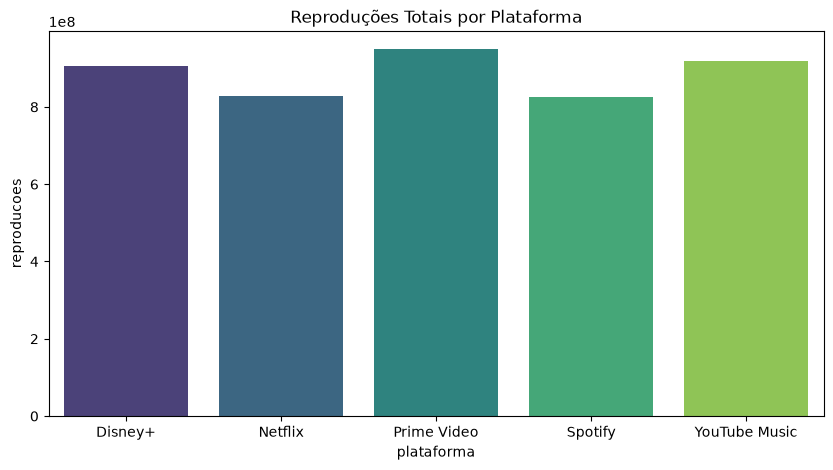

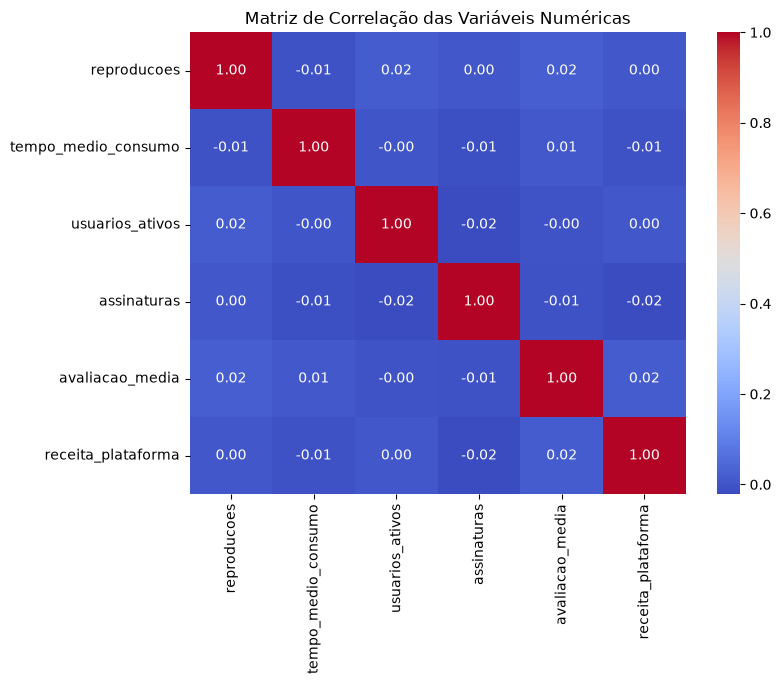

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df.groupby("plataforma")["reproducoes"].sum().reset_index(),
    x="plataforma",
    y="reproducoes",
    hue="plataforma",
    palette="viridis",
    legend=False,
)
plt.title("Reproduções Totais por Plataforma")
plt.show()

plt.figure(figsize=(8, 6))
colunas_numericas = df[
    [
        "reproducoes",
        "tempo_medio_consumo",
        "usuarios_ativos",
        "assinaturas",
        "avaliacao_media",
        "receita_plataforma",
    ]
]
sns.heatmap(colunas_numericas.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

## 7. Interpretação e Conclusão
**Interpretação:** Pelos gráficos de barras, observamos a clara liderança e preferência em nichos de conteúdos específicos. A matriz de correlação demonstra as variáveis que caminham lado a lado no faturamento de assinaturas.

**Conclusão:** O mercado digital continua em ascensão, com demandas variadas por gêneros, demandando uma análise constante para impulsionar e otimizar campanhas e recomendações no painel de cada usuário final.